In [39]:
import sys
sys.path.insert(0, '..')

In [40]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [41]:
wid = 80
oversample = 4

nwavels = 30
npoly=4

n_modes = 5
n_zernikes = 10

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

vects = np.load("../data/iterative_spectrum_basis_F110W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))




exposures_single = [
    exposure_from_file(ddir + 'n8zu81fbq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid),
    # exposure_from_file(ddir + 'n8zu81fcq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid),
]


159.962 5.4
Version 4.1.1
31.1289


/Users/haydengreer/PhD/hst/coron/notebooks/../models.py:182: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam, orient)


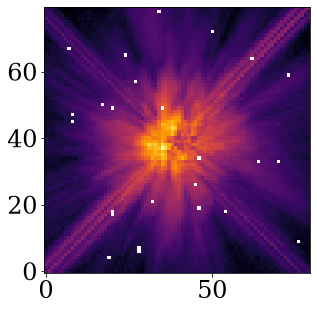

In [42]:
plt.imshow(exposures_single[0].data**0.125)

In [43]:
exposures_single[0].target

'PSF-1-M0'

In [44]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},

    "bias": {},
    "occulter_radius": 0.76,
    "fnumber": 45.3,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*6)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([0.00, 0.])
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.3, -0.1])

    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.array([-160.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([-13.,-7.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 0.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

57.53866862274662


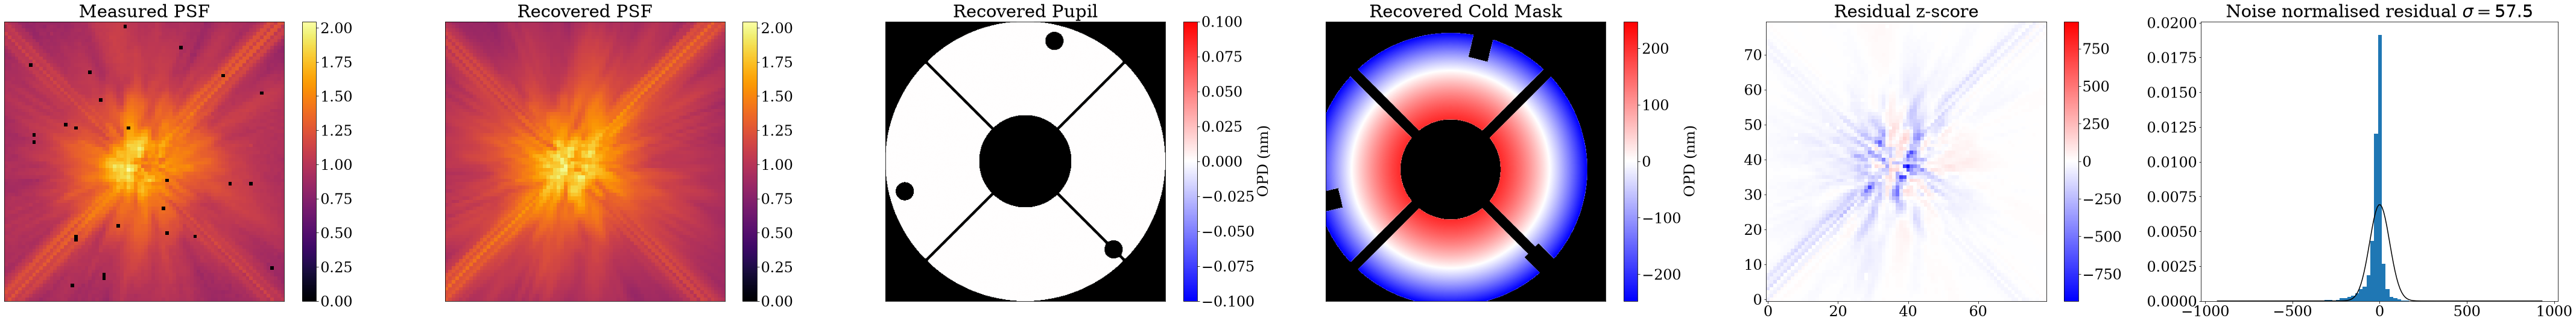

In [45]:
plot_comparison(model_single, params, exposures_single)

In [46]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "spectrum": sgd(g*3, 0),
    # "primary_opd": sgd(g*3, 20),
    "primary_low": sgd(g*3, 10),
    "primary_tilt": sgd(g*1., 10),
    "cold_mask_tilt": sgd(g*1, 10),
    "cold_mask_opd": sgd(g*1, 10),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*20, 60),
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [47]:
# orig_params = params.params
# opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [48]:
# losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

In [49]:
# plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [50]:
orig_params = params.params #| params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [51]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 50, nbatches=5)

  0%|          | 0/50 [00:00<?, ?it/s]

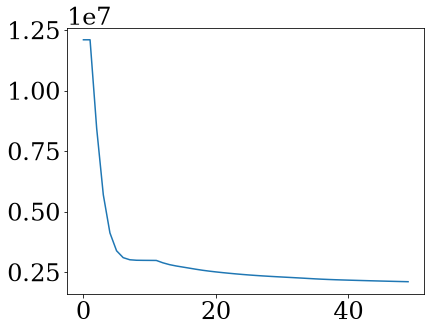

In [52]:
plt.plot(losses[:])

In [53]:
losses[-1]

Array(2104965.96005097, dtype=float64)

7
24.268049049509113


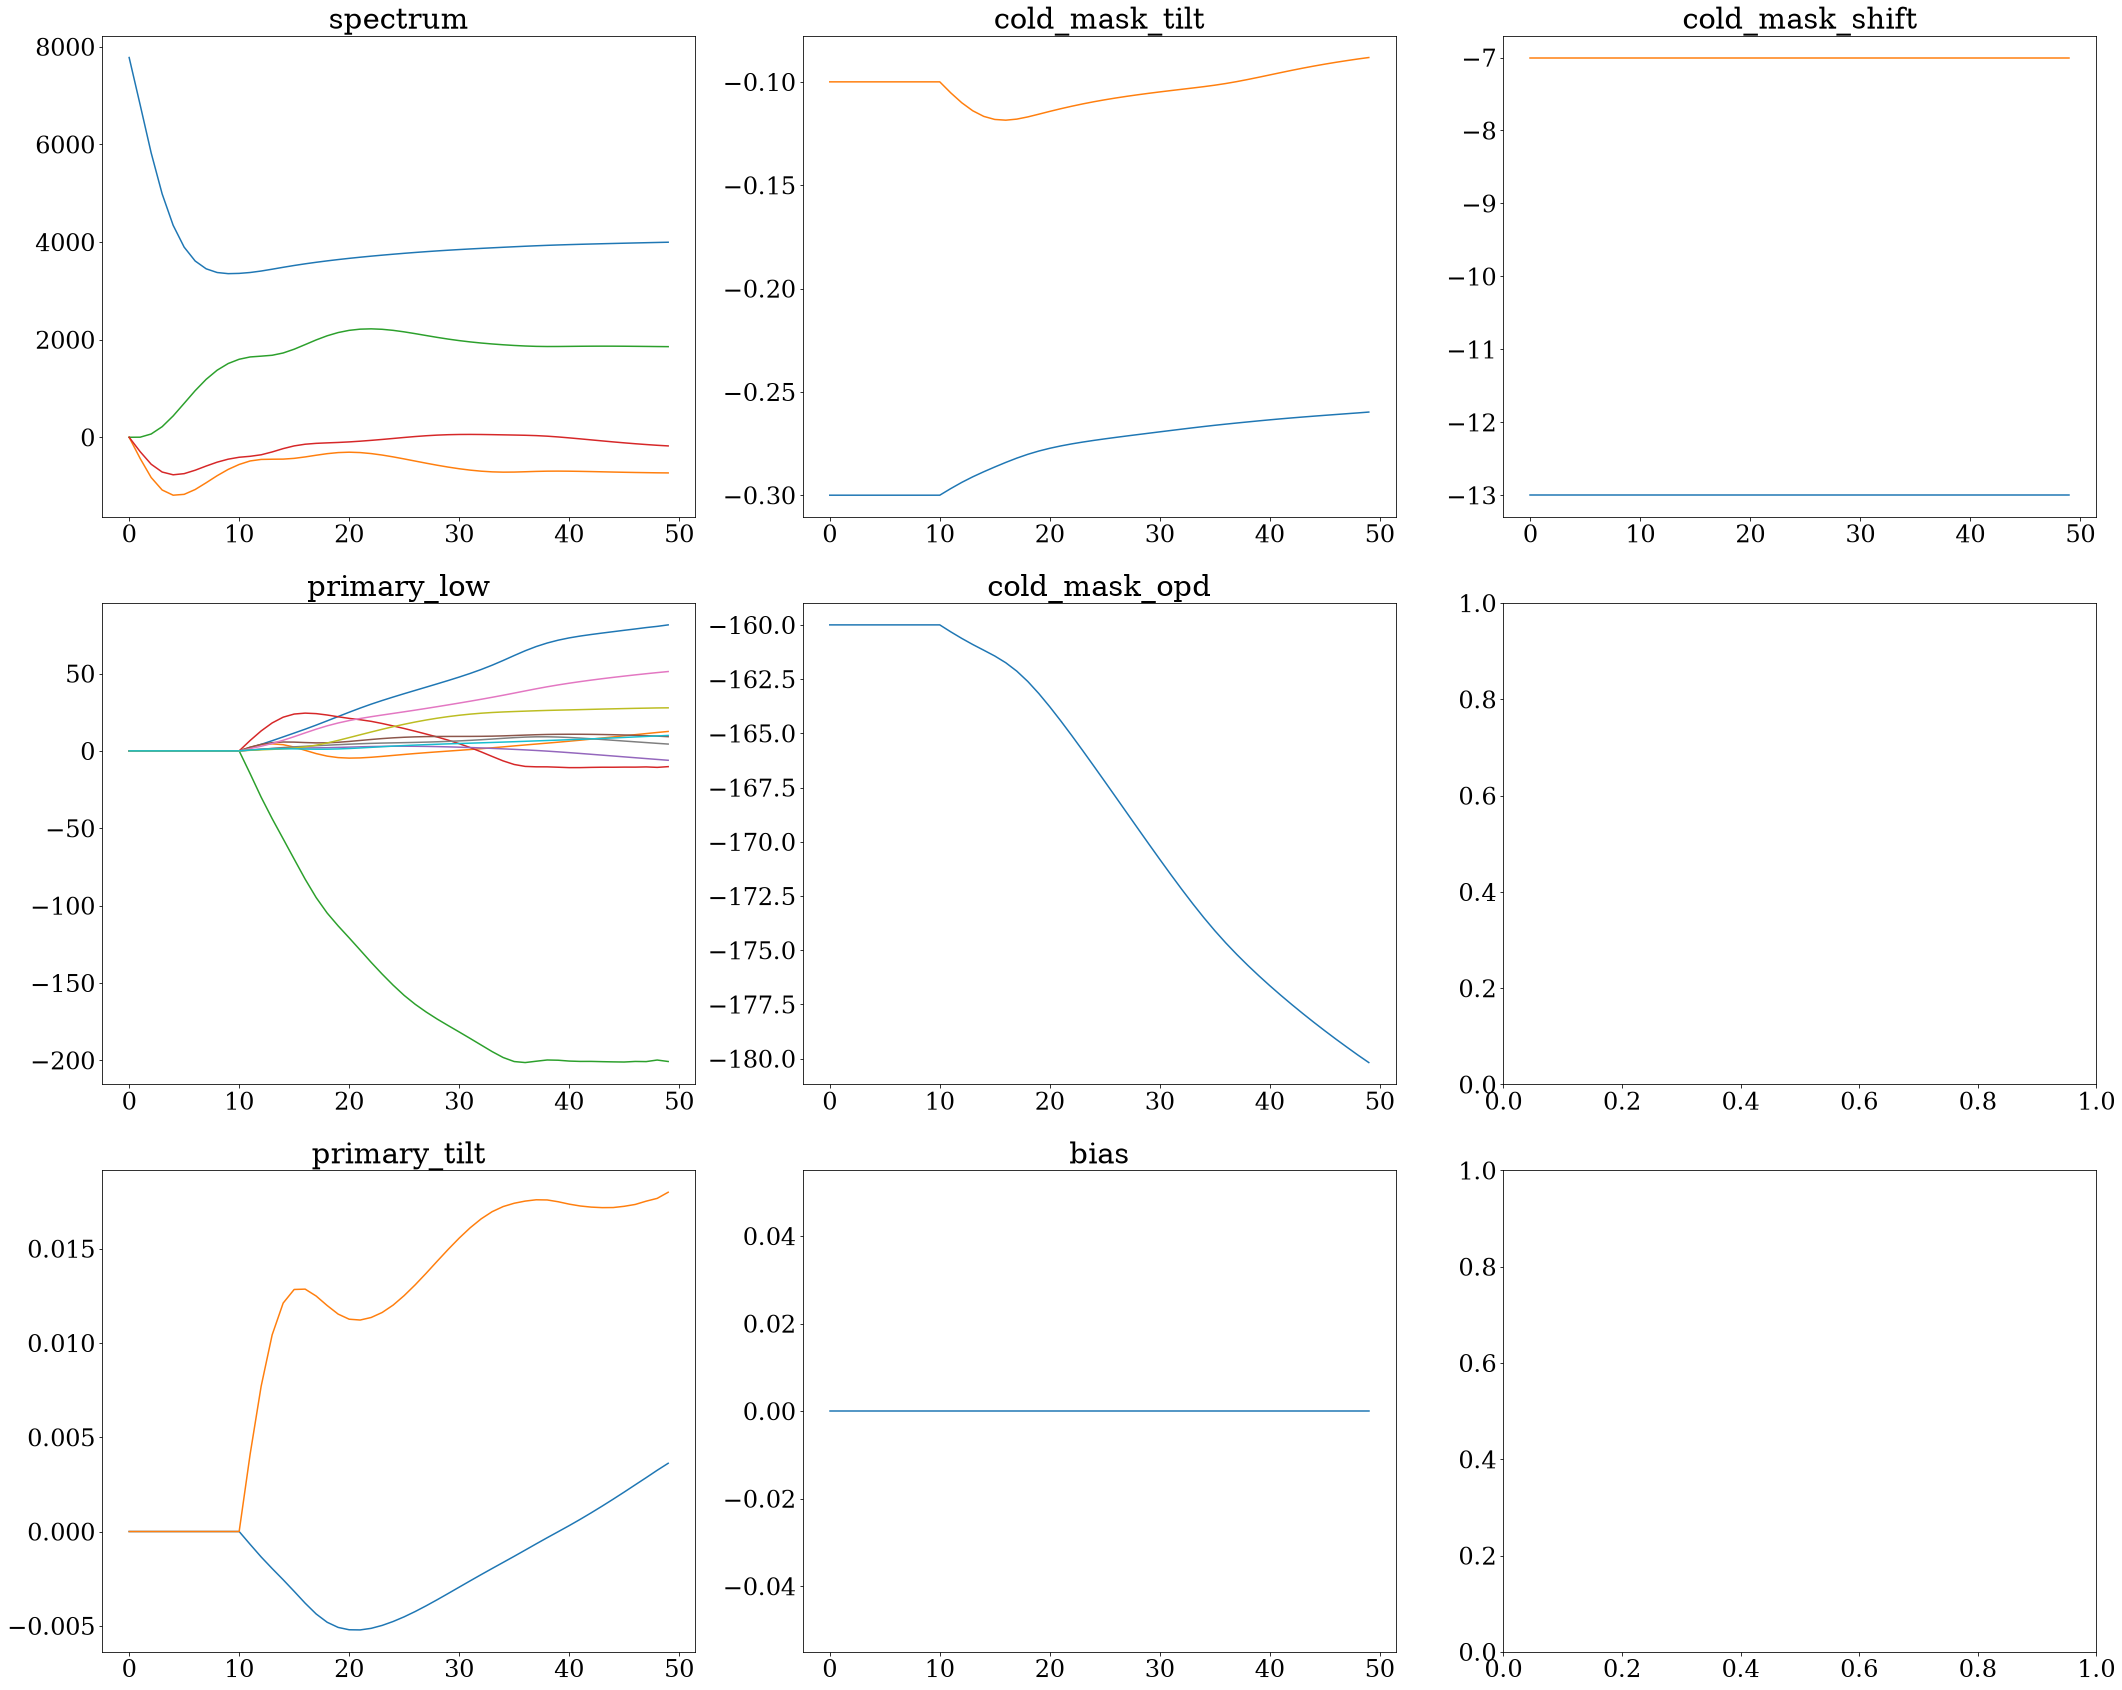

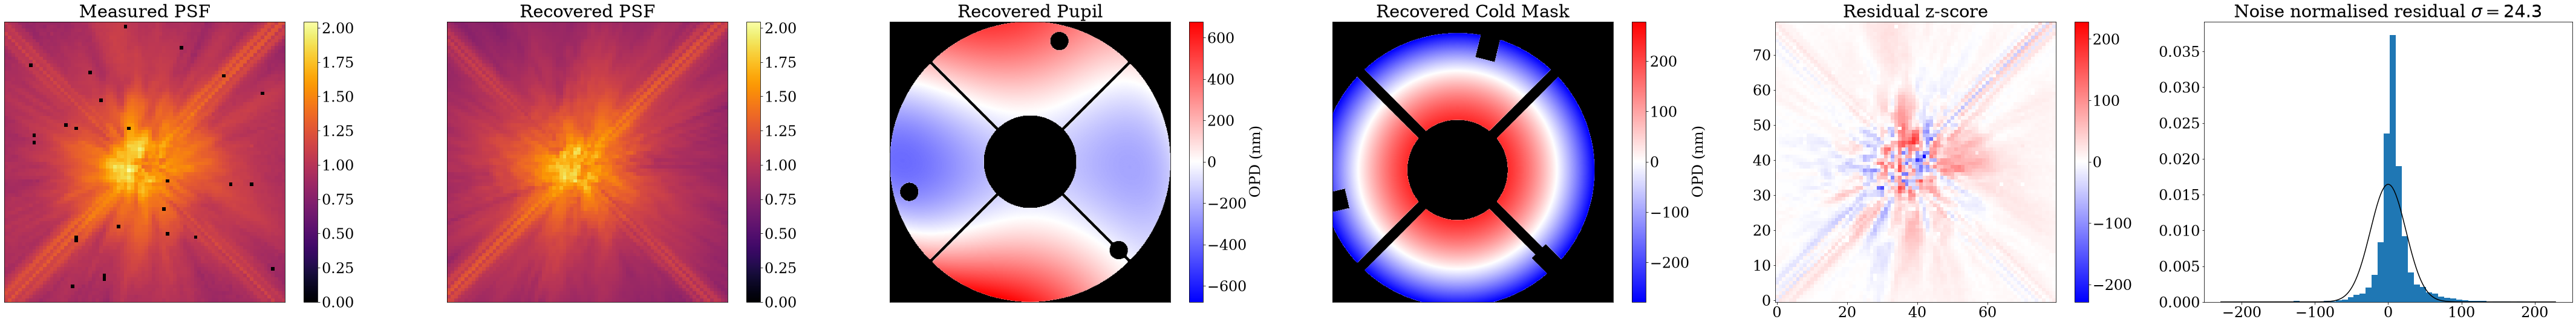

In [54]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False)

In [55]:
params_history[-1]

{'bias': {'n8zu81fbq': Array(0., dtype=float64)},
 'cold_mask_opd': {'global': Array([-180.18176525], dtype=float64)},
 'cold_mask_shift': {'global': Array([-13.,  -7.], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.25977616, -0.08822796], dtype=float64)},
 'primary_low': {'n8zu81fbq': Array([  81.46574346,   12.56751361, -200.80958196,  -10.18181414,
           -6.07088064,    9.20231538,   51.30306297,    4.41283955,
           27.83710573,    9.98557784], dtype=float64)},
 'primary_tilt': {'n8zu81fbq': Array([0.0036183 , 0.01799008], dtype=float64)},
 'spectrum': {'PSF-1-M0_F110W': Array([3995.23966799, -730.07265044, 1856.17442983, -177.11205438],      dtype=float64)}}